<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/copia_de_tienda_retail_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df= pd.read_csv('/content/drive/MyDrive/CURSOPYTHON/retail_sales_dataset (1).csv')

# Taraea 3 del mismo ejercicio de ventas


## 1. Limpieza y Preparación de Datos
En esta sección, nos aseguramos de que los tipos de datos sean correctos y verificamos la integridad de los cálculos financieros.

In [7]:
#   Primero hay que corregir el formato de fechas
df['Date']= pd.to_datetime(df['Date'])


### Corrección de Fechas
Transformamos la columna `Date` para que Python la reconozca como un objeto temporal, permitiéndonos realizar análisis basados en el tiempo (meses, días, etc.).

In [8]:
# Tenemos que recalcular y verificar los ingresos totales por ventas
df['Total_Revenue']= df['Quantity'] * df['Price per Unit']

### Verificación de Ingresos
Calculamos manualmente `Total_Revenue` multiplicando la cantidad por el precio unitario. Esto nos permite confirmar que el monto registrado originalmente es correcto.

In [9]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total_Revenue
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100


## 2. Ingeniería de Características (Feature Engineering)
Creamos nuevas variables para segmentar mejor la información y normalizar los datos para futuros modelos estadísticos.


In [10]:
df['Ventas_Normalizada']= (df['Total Amount'] - df['Total Amount'].min()) / (df['Total Amount'].max() - df['Total Amount'].min())

### Ingeniería de Características (Feature Engineering)

Creamos nuevas métricas para profundizar en el análisis:
* **Normalización:** Escalamos las ventas entre 0 y 1 para comparar magnitudes.
* **Categorización (Binning):** Clasificamos las ventas en niveles (Baja, Media, Alta).
* **Segmentación:** Agrupamos a los clientes por rango de edad (Joven, Adulto, Adulto Mayor).

In [11]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total_Revenue,Ventas_Normalizada
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150,0.063291
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000,0.493671
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30,0.002532
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500,0.240506
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100,0.037975


In [12]:
etiqueta_calidad= ['Baja', 'Media', 'Alta']
df['Nivel_Venta']= pd.qcut(df['Total Amount'], q= 3, labels=etiqueta_calidad)

In [13]:
def clasificar_por_client(edad):
    if edad<30:
        return 'Joven'
    elif edad <= 50:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

df['Segmento_Cliente']= df['Age'].apply(clasificar_por_client)

In [14]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total_Revenue,Ventas_Normalizada,Nivel_Venta,Segmento_Cliente
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150,0.063291,Media,Adulto
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000,0.493671,Alta,Joven
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30,0.002532,Baja,Adulto
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500,0.240506,Media,Adulto
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100,0.037975,Media,Adulto


## 3. Agrupación y Estadísticas Descriptivas

En esta fase del análisis, consolidamos los datos para entender el comportamiento de las ventas por categoría y género. Extraemos métricas clave como sumas, promedios y medidas de dispersión.


## Agrupación y Agregación
* Agrupación por múltiples columnas: Realiza agrupaciones por categorías como producto y tienda, producto y mes, etc.
* Aplicar funciones de agregación: Utiliza funciones como sum, mean, count, min, max, std, y var para obtener estadísticas descriptivas de cada grupo.

### Extracción de Meses
Obtenemos el nombre del mes de cada transacción para que los reportes de agrupación posteriores sean fáciles de interpretar.

In [15]:
# primero se debe extraer los nombres de los meses para mejor lejibilidad

df['Meses']= df['Date'].dt.month_name()

In [16]:
#Vamos a ver quien es el que esta gastando mass poor categoria desde multiples columnas "Productos y Genero"
resumen_por_producto_genero = df.groupby(['Product Category', 'Gender'])['Total Amount'].agg(['sum', 'mean', 'count'])
print("Ventas por genero")
print(resumen_por_producto_genero)

Ventas por genero
                           sum        mean  count
Product Category Gender                          
Beauty           Female  74830  450.783133    166
                 Male    68685  487.127660    141
Clothing         Female  81275  467.097701    174
                 Male    74305  419.802260    177
Electronics      Female  76735  451.382353    170
                 Male    80170  466.104651    172


### Análisis de Frecuencia y Volumen
Agrupamos los datos por categoría de producto y género para identificar patrones de consumo y el volumen total de transacciones.

In [17]:
# Cuantas Ventas se obtuvieron de cada cosa

print(df.groupby('Product Category')['Total Amount'].count())

Product Category
Beauty         307
Clothing       351
Electronics    342
Name: Total Amount, dtype: int64


In [18]:
# Dinero total ingresado

print(df.groupby('Product Category')['Total Amount'].sum())

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


### Análisis de Valores Extremos y Promedios
Calculamos el valor medio, mínimo y máximo de las ventas por categoría para entender el rango de precios de nuestro inventario.

In [19]:
# Valor medio de cada parte

print(df.groupby('Product Category')['Total Amount'].mean())

Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64


In [20]:
#Ventas mas varatas y mas caras

print("<<<<Minimo>>>>")
print(df.groupby('Product Category')['Total Amount'].min())

print("<<<<Maximo>>>>")
print(df.groupby('Product Category')['Total Amount'].max())

<<<<Minimo>>>>
Product Category
Beauty         25
Clothing       25
Electronics    25
Name: Total Amount, dtype: int64
<<<<Maximo>>>>
Product Category
Beauty         2000
Clothing       2000
Electronics    2000
Name: Total Amount, dtype: int64


### Análisis de Variabilidad (Dispersión)
Calculamos la **Desviación Estándar** y la **Varianza** por categoría. Esto nos indica si los precios en una categoría son uniformes o si varían significativamente entre productos.

In [21]:
#Dispercion de las ventas

print(df.groupby('Product Category')['Total Amount'].std())

Product Category
Beauty         563.612788
Clothing       550.695917
Electronics    567.540150
Name: Total Amount, dtype: float64


In [22]:
# Varianza de la informacino de productos categeoria

print(df.groupby('Product Category')['Total Amount'].var())

Product Category
Beauty         317659.374401
Clothing       303265.992674
Electronics    322101.822341
Name: Total Amount, dtype: float64


## 3. Análisis de Desviación
Calculamos qué tanto se aleja cada venta individual del promedio de su categoría para identificar comportamientos inusuales o clientes destacados.


## 4. Análisis de Desviación Personalizado

Aquí aplicamos una lógica avanzada: calculamos qué tanto se aleja cada venta individual del promedio de su propia categoría.

* **Desviación Positiva:** Ventas por encima de la media (clientes de alto valor).
* **Desviación Negativa:** Ventas por debajo de la media.

## Análisis Personalizado con apply
* Función personalizada: Aplica funciones personalizadas para realizar análisis específicos que no se pueden lograr con las funciones de agregación estándar.
* Ejemplo de uso avanzado: Calcula la desviación de cada venta respecto a la media de su grupo.

In [23]:
# Primero definir una funcion como logica para la desviacion

def calculadora_deviacion(ser):
    media_grupo = ser.mean()
    return ser - media_grupo

In [24]:
# Creacion de nueva column comprandando cada registro de ventas con su promedio.
df['Desviacion_Categoria']= df.groupby('Product Category')['Total Amount'].transform(calculadora_deviacion)

In [25]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total_Revenue,Ventas_Normalizada,Nivel_Venta,Segmento_Cliente,Meses,Desviacion_Categoria
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150,0.063291,Media,Adulto,November,-317.475570
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000,0.493671,Alta,Joven,February,556.752137
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30,0.002532,Baja,Adulto,January,-428.786550
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500,0.240506,Media,Adulto,May,56.752137
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100,0.037975,Media,Adulto,May,-367.475570


In [26]:
# Analisis de resultados
#Valor positivo: Cliente gasto mas que el promedio
#Valor negativo: El cliente gasto menos que el promedio
#Cerca del 0: Es una venta estandar.
ventas_atipicas= df[['Transaction ID', 'Product Category', 'Total Amount', 'Desviacion_Categoria']].sort_values(by='Desviacion_Categoria', ascending= False)

In [27]:
ventas_atipicas

,Transaction ID,Product Category,Total Amount,Desviacion_Categoria
419,420,Clothing,2000,1556.752137
475,476,Clothing,2000,1556.752137
252,253,Clothing,2000,1556.752137
268,269,Clothing,2000,1556.752137
560,561,Clothing,2000,1556.752137
...,...,...,...,...
362,363,Beauty,25,-442.475570
308,309,Beauty,25,-442.475570
203,204,Beauty,25,-442.475570
944,945,Beauty,25,-442.475570


### Identificación de Ventas Atípicas
Finalmente, ordenamos los registros basándonos en su nivel de desviación para detectar rápidamente las transacciones más inusuales o significativas.

In [28]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total_Revenue,Ventas_Normalizada,Nivel_Venta,Segmento_Cliente,Meses,Desviacion_Categoria
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150,0.063291,Media,Adulto,November,-317.475570
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000,0.493671,Alta,Joven,February,556.752137
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30,0.002532,Baja,Adulto,January,-428.786550
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500,0.240506,Media,Adulto,May,56.752137
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100,0.037975,Media,Adulto,May,-367.475570


In [29]:
print(df[['Age', 'Quantity', 'Price per Unit', 'Total_Revenue']].describe())

              Age     Quantity  Price per Unit  Total_Revenue
count  1000.00000  1000.000000     1000.000000    1000.000000
mean     41.39200     2.514000      179.890000     456.000000
std      13.68143     1.132734      189.681356     559.997632
min      18.00000     1.000000       25.000000      25.000000
25%      29.00000     1.000000       30.000000      60.000000
50%      42.00000     3.000000       50.000000     135.000000
75%      53.00000     4.000000      300.000000     900.000000
max      64.00000     4.000000      500.000000    2000.000000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Transaction ID        1000 non-null   int64         
 1   Date                  1000 non-null   datetime64[ns]
 2   Customer ID           1000 non-null   object        
 3   Gender                1000 non-null   object        
 4   Age                   1000 non-null   int64         
 5   Product Category      1000 non-null   object        
 6   Quantity              1000 non-null   int64         
 7   Price per Unit        1000 non-null   int64         
 8   Total Amount          1000 non-null   int64         
 9   Total_Revenue         1000 non-null   int64         
 10  Ventas_Normalizada    1000 non-null   float64       
 11  Nivel_Venta           1000 non-null   category      
 12  Segmento_Cliente      1000 non-null   object        
 13  Meses              

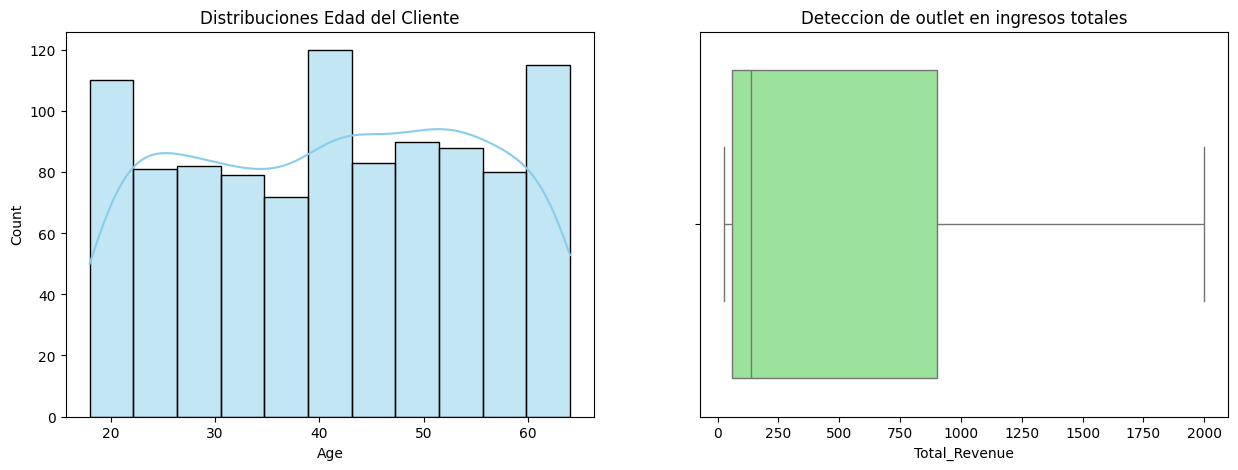

In [31]:
fig, ax,= plt.subplots(1, 2, figsize=(15,5))
sns.histplot(df['Age'], kde= True, ax= ax[0], color='skyblue')
ax[0].set_title('Distribuciones Edad del Cliente')
sns.boxplot(x=df['Total_Revenue'], ax=ax[1], color='lightgreen')
ax[1].set_title('Deteccion de outlet en ingresos totales')
plt.show()


### Distribución de Edad y Detección de Atípicos en Ingresos

Este gráfico se compone de dos subplots:

1.  **Histograma de Edad de Clientes (izquierda):** Muestra la distribución de la edad de los clientes. Permite identificar los rangos de edad con mayor concentración de clientes.

2.  **Boxplot de Ingresos Totales (derecha):** Visualiza la distribución de los `Total_Revenue` y ayuda a identificar valores atípicos (outliers) en los ingresos. Los puntos fuera de los bigotes del boxplot representan transacciones con ingresos inusualmente altos o bajos.

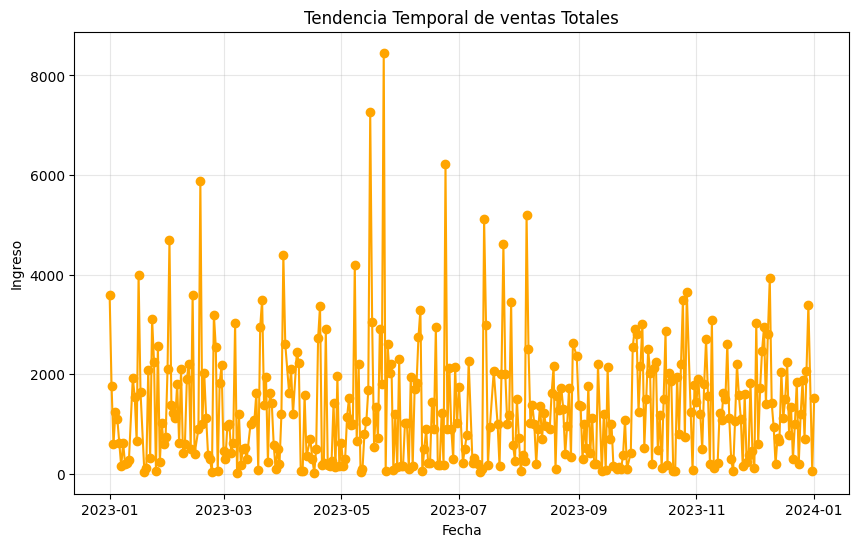

In [32]:
plt.figure(figsize=(10, 6))
df_diario= df.groupby('Date')['Total_Revenue'].sum().reset_index()
plt.plot(df_diario['Date'], df_diario['Total_Revenue'], marker='o', linestyle='-', color='orange')
plt.title('Tendencia Temporal de ventas Totales')
plt.xlabel('Fecha')
plt.ylabel('Ingreso')
plt.grid(True, alpha=0.3)
plt.show()

### Tendencia Temporal de Ventas Totales

Este gráfico de líneas muestra la evolución diaria de los ingresos totales (`Total_Revenue`) a lo largo del tiempo. Permite observar patrones, tendencias (crecimiento o decrecimiento) y fluctuaciones estacionales o eventos específicos que pudieron haber impactado las ventas.

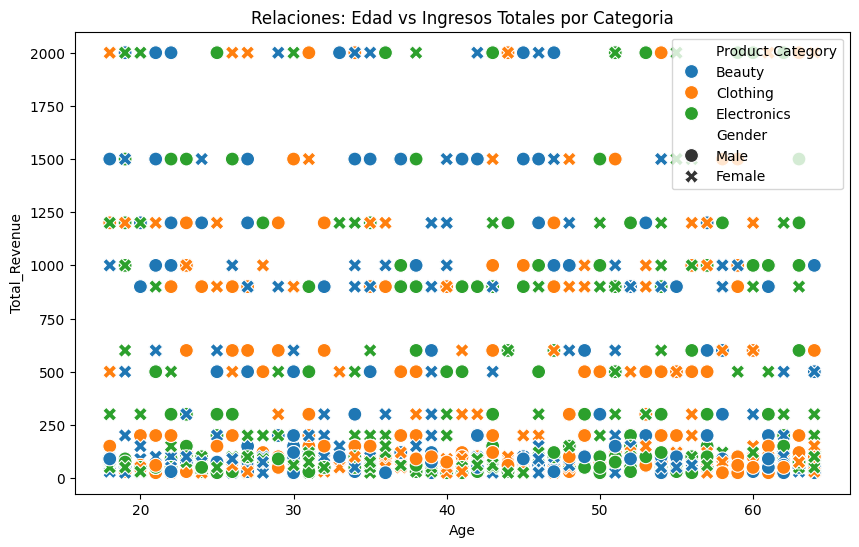

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Total_Revenue', hue='Product Category', style='Gender', s=100)
plt.title('Relaciones: Edad vs Ingresos Totales por Categoria')
plt.show()

### Relación entre Edad, Ingresos y Categoría de Producto

Este gráfico de dispersión explora la relación entre la edad del cliente (`Age`) y los ingresos totales de la transacción (`Total_Revenue`).

*   Los puntos están codificados por color según la `Product Category` (Categoría de Producto).
*   La forma de los puntos varía según el `Gender` (Género) del cliente.

Esto ayuda a identificar si ciertos grupos de edad o géneros tienden a gastar más en categorías de productos específicas.

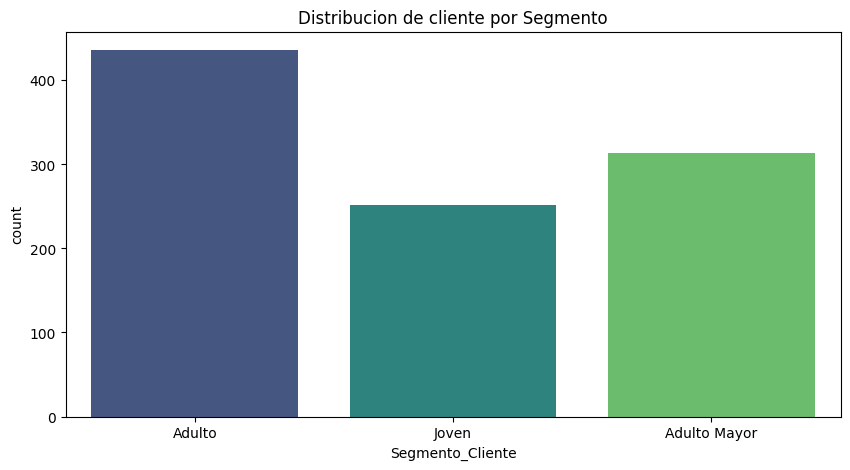

In [34]:
plt.figure(figsize=(10,5 ))
sns.countplot(data=df, x='Segmento_Cliente', palette='viridis', hue='Segmento_Cliente', legend=False)
plt.title('Distribucion de cliente por Segmento')
plt.show()

### Distribución de Clientes por Segmento

Este gráfico de barras muestra la cantidad de clientes en cada `Segmento_Cliente` (Joven, Adulto, Adulto Mayor). Permite visualizar la proporción de clientes en cada categoría demográfica y entender la composición de la base de clientes.

In [35]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total_Revenue,Ventas_Normalizada,Nivel_Venta,Segmento_Cliente,Meses,Desviacion_Categoria
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150,0.063291,Media,Adulto,November,-317.475570
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000,0.493671,Alta,Joven,February,556.752137
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30,0.002532,Baja,Adulto,January,-428.786550
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500,0.240506,Media,Adulto,May,56.752137
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100,0.037975,Media,Adulto,May,-367.475570


In [36]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total_Revenue,Ventas_Normalizada,Nivel_Venta,Segmento_Cliente,Meses,Desviacion_Categoria
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150,0.063291,Media,Adulto,November,-317.475570
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000,0.493671,Alta,Joven,February,556.752137
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30,0.002532,Baja,Adulto,January,-428.786550
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500,0.240506,Media,Adulto,May,56.752137
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100,0.037975,Media,Adulto,May,-367.475570


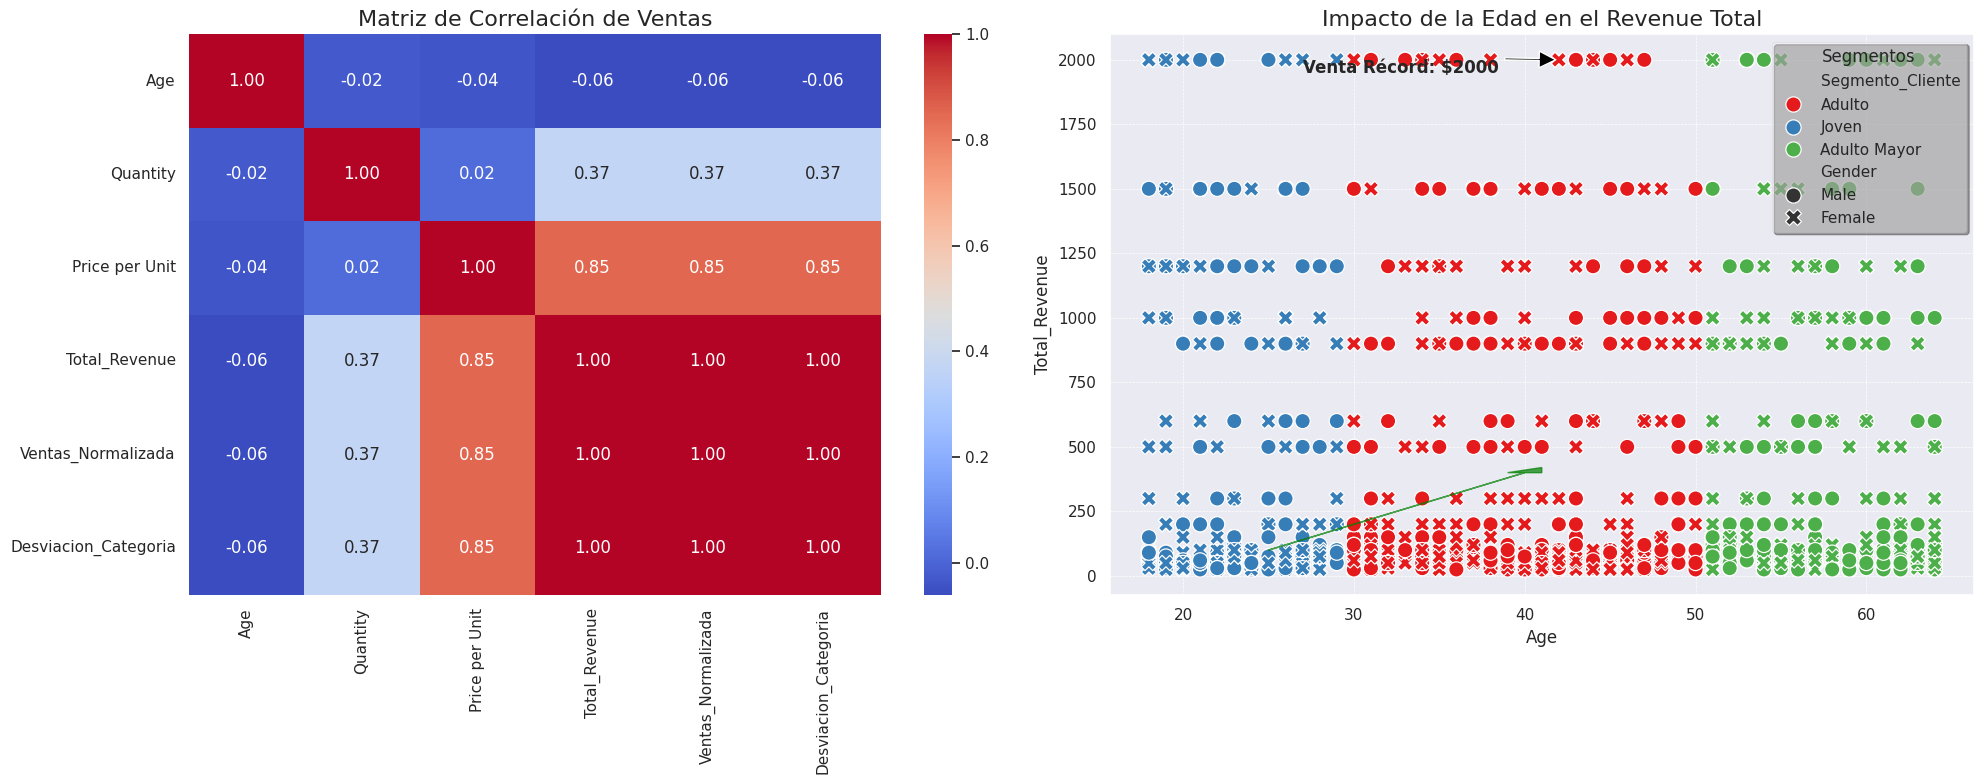

In [59]:
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#EAEAF2"})
fig, ax= plt.subplots(1, 2, figsize=(20, 8))
cols_num= ['Age', 'Quantity', 'Price per Unit', 'Total_Revenue', 'Ventas_Normalizada', 'Desviacion_Categoria']
corr_matrix= df[cols_num].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax[0])
ax[0].set_title('Matriz de Correlación de Ventas', fontsize=16)


scatter= sns.scatterplot(data=df, x='Age', y='Total_Revenue',
                          hue='Segmento_Cliente', style='Gender',
                          s=120, palette='Set1', ax=ax[1])

ax[1].set_title('Impacto de la Edad en el Revenue Total', fontsize=16)
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5, color='white')

ax[1].legend(loc='upper right', title='Segmentos', framealpha=0.3, facecolor='white', shadow=True)


max_sale= df.loc[df['Total_Revenue'].idxmax()]

ax[1].annotate(f'Venta Récord: ${max_sale["Total_Revenue"]}',
               xy=(max_sale['Age'], max_sale['Total_Revenue']),
               xytext=(max_sale['Age'] - 15, max_sale['Total_Revenue'] - 50),
               arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
               fontsize=12, fontweight='bold')

ax[1].arrow(25, 100, 15, 300, head_width=2, head_length=20, fc='green', ec='green', alpha=0.7)

plt.tight_layout()
plt.show()